## COVID Drivers: Modeling

This notebook models

AGGRESSIVE_DRIVING ~
* POST_COVID
* CELL_PHONE
* IMPAIRED_DRIVER
* MATURE_DRIVER
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* HIT_RUN
* UNLICENSED
* URBAN_RURALx

AGGRESSIVE_DRIVING ~
* POST_COVID
* IMPAIRED_DRIVER
* CELL_PHONE
* YOUNG_DRIVER
* FATIGUE_ASLEEP
* POST_COVID*IMPAIRED_DRIVER
* POST_COVID*CELL_PHONE
* POST_COVID*YOUNG_DRIVER
* POST_COVID*FATIGUE_ASLEEP

using logistic regression with Scikit Learn and Statsmodels

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Logistic Regression with Cross Validation](#lgr-cv)</BR>
* [Logistic Regression with Statsmodels](#sm)</BR>
* [Logistic Regression with Cross Validation and Interaction](#lgr-cv-int)</BR>
* [Preprocessing with Interaction](#prep-int)</BR>
* [Logistic Regression with Statsmodels and Interaction](#sm-int)</BR>
* [Preprocessing for Time-Based Robustness Testing](#prep-rob)</BR>
* [Robustness Testing with Statsmodels](#sm-rob)



Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import xgboost as xgb
from functools import reduce
#import prince

import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, classification_report, RocCurveDisplay
from scipy.interpolate import interp1d

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [4]:
df_init = pd.read_csv(path_in, low_memory=False)

In [5]:
df_init['AGGRESSIVE_DRIVING'].sum()/df_init.shape[0]

np.float64(0.5598028680536025)

In [6]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [7]:
df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')]['AGGRESSIVE_DRIVING'].sum()/df_init.loc[df_init['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].shape[0]

np.float64(0.5563778090234096)

In [8]:
df = df_init.copy()

In [9]:
df['POST_COVID_FATIGUE'] = df['POST_COVID']*df['FATIGUE_ASLEEP']

In [10]:
df['POST_COVID_YOUNG'] = df['POST_COVID']*df['YOUNG_DRIVER']

In [11]:
df['POST_COVID_PHONE'] = df['POST_COVID']*df['CELL_PHONE']

In [12]:
df['POST_COVID_IMPAIRED'] = df['POST_COVID']*df['IMPAIRED_DRIVER']

In [13]:
df.columns.tolist()

['CRN',
 'CRASH_DATE',
 'POST_COVID',
 'ALCOHOL_RELATED',
 'CELL_PHONE',
 'DISTRACTED',
 'DRINKING_DRIVER',
 'DRIVER_16YR',
 'DRIVER_17YR',
 'DRIVER_18YR',
 'DRIVER_19YR',
 'DRIVER_20YR',
 'DRIVER_50_64YR',
 'DRIVER_65_74YR',
 'DRIVER_75PLUS',
 'DRUGGED_DRIVER',
 'DRUG_RELATED',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'ILLEGAL_DRUG_RELATED',
 'IMPAIRED_DRIVER',
 'IMPAIRED_NONMOTORIST',
 'MARIJUANA_DRUGGED_DRIVER',
 'MARIJUANA_RELATED',
 'MATURE_DRIVER',
 'MC_DRINKING_DRIVER',
 'OPIOID_RELATED',
 'UNDERAGE_DRNK_DRV',
 'UNLICENSED',
 'YOUNG_DRIVER',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING',
 'COUNTYx',
 'URBAN_RURALx',
 'POST_COVID_FATIGUE',
 'POST_COVID_YOUNG',
 'POST_COVID_PHONE',
 'POST_COVID_IMPAIRED']

In [14]:
df['URBAN_RURALx'].unique()

array(['Rural', 'Urbanized'], dtype=object)

### <a id='prep'>Preprocessing</a>

In [15]:
X = df.loc[:,['POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED',
 'URBAN_RURALx']].copy()

In [16]:
y = df['AGGRESSIVE_DRIVING']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [18]:
categorical_cols = ['URBAN_RURALx']

In [19]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='passthrough'
    )

In [21]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='lgr-cv'>Logistic Regression with Cross Validation</a>

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
lgr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', penalty = 'elasticnet', l1_ratios=[0, 0.25, 0.5, 0.75, 1], max_iter=5000))
])

In [24]:
lgr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['URBAN_RURALx'])])),
                ('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0, 0.25, 0.5, 0.75, 1],
                                      max_iter=5000, penalty='elasticnet',
                                      random_state=42, solver='saga'))])

#### Features importances

In [25]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [26]:
# Get Feature Names from Preprocessor - ColumnTransformer
feature_names = lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [27]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [28]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [29]:
print(feature_importance_df)

                       Feature  Importance
7    remainder__FATIGUE_ASLEEP    1.993392
3        remainder__CELL_PHONE    1.129910
4   remainder__IMPAIRED_DRIVER    0.527482
6      remainder__YOUNG_DRIVER    0.496793
5     remainder__MATURE_DRIVER    0.300446
8           remainder__HIT_RUN    0.175152
9        remainder__UNLICENSED    0.084264
0      cat__URBAN_RURALx_Rural    0.078040
1  cat__URBAN_RURALx_Urbanized    0.078024
2        remainder__POST_COVID    0.033660


In [30]:
feature_names

array(['cat__URBAN_RURALx_Rural', 'cat__URBAN_RURALx_Urbanized',
       'remainder__POST_COVID', 'remainder__CELL_PHONE',
       'remainder__IMPAIRED_DRIVER', 'remainder__MATURE_DRIVER',
       'remainder__YOUNG_DRIVER', 'remainder__FATIGUE_ASLEEP',
       'remainder__HIT_RUN', 'remainder__UNLICENSED'], dtype=object)

In [31]:
feature_names2 = []

for i, v in enumerate(feature_names):
  #print('Feature: %s' % (v))
  new = v.split('__')[1]
  if 'urban' in new.lower():
    new = new.split('_')[2].upper()
  feature_names2.append(new)

feature_names2


['RURAL',
 'URBANIZED',
 'POST_COVID',
 'CELL_PHONE',
 'IMPAIRED_DRIVER',
 'MATURE_DRIVER',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
 'HIT_RUN',
 'UNLICENSED']

In [32]:
colors = ['teal', 'cadetblue', 'mediumaquamarine', 'seagreen', 'darkgreen', 'lightseagreen', 'skyblue', 'dodgerblue', 'royalblue', 'navy']

Feature: RURAL, Score: 0.07804
Feature: URBANIZED, Score: 0.07802
Feature: POST_COVID, Score: 0.03366
Feature: CELL_PHONE, Score: 1.12991
Feature: IMPAIRED_DRIVER, Score: 0.52748
Feature: MATURE_DRIVER, Score: 0.30045
Feature: YOUNG_DRIVER, Score: 0.49679
Feature: FATIGUE_ASLEEP, Score: 1.99339
Feature: HIT_RUN, Score: 0.17515
Feature: UNLICENSED, Score: 0.08426


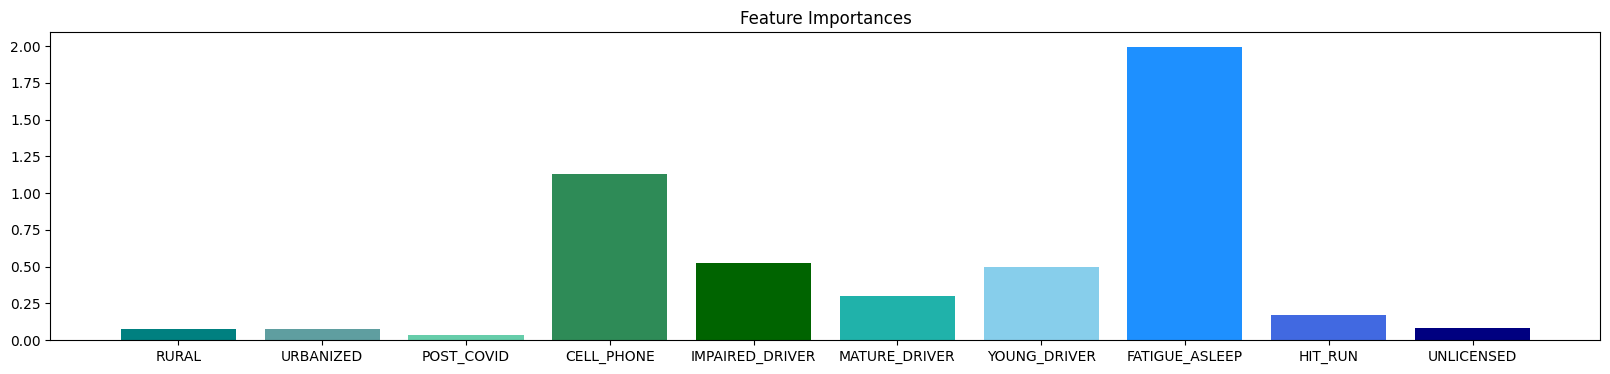

In [33]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names2[i],v))
# plot feature importance
plt.bar(feature_names2, importances, color=colors)
fig = plt.gcf() # Get current figure
fig.set_size_inches(20, 4)
plt.title('Feature Importances')
plt.show()

#### Confusion matrix

In [34]:
y_pred = lgr_pipeline.predict(X_test)

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 59.14%


In [36]:
conf_matrix = confusion_matrix(y_test, y_pred)

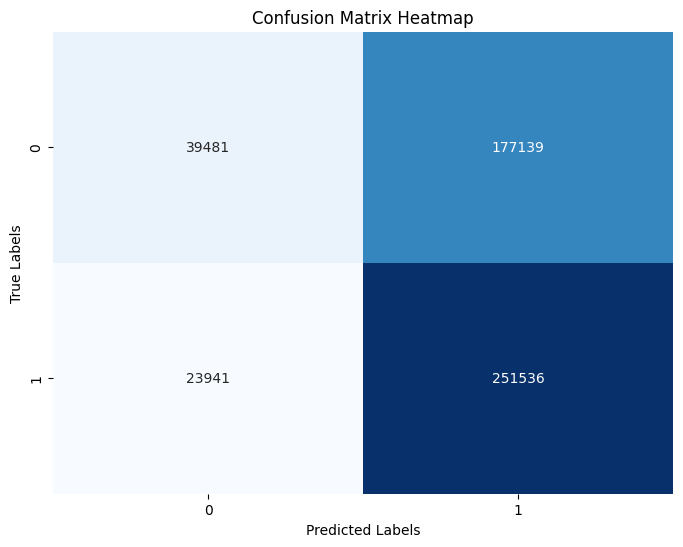

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Performance metrics

In [38]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [39]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [40]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [41]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [42]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

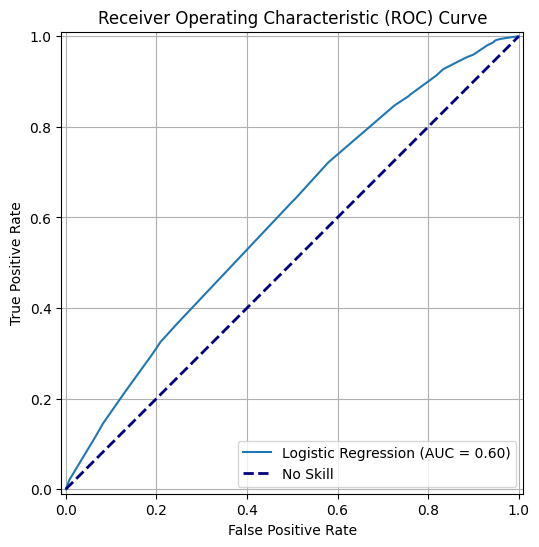

In [43]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [44]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [45]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [46]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [47]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5914
1,Precision,0.5868
2,Recall,0.9131
3,F1 Score,0.7144
4,ROC AUC,0.6012


In [48]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.18      0.28    216620
           1       0.59      0.91      0.71    275477

    accuracy                           0.59    492097
   macro avg       0.60      0.55      0.50    492097
weighted avg       0.60      0.59      0.52    492097



### <a id='sm'>Logistic Regression with Statsmodels</a>

In [49]:
lgr_pipeline = Pipeline(steps=[
    ('add_constant', add_constant_func),
    ('preprocessor', preprocessor)
])

In [50]:
X_train_const = lgr_pipeline.named_steps['add_constant'].fit_transform(X_train)
X_test_const = lgr_pipeline.named_steps['add_constant'].transform(X_test)

In [51]:
X_train_trx = lgr_pipeline.named_steps['preprocessor'].fit_transform(X_train_const)
X_test_trx = lgr_pipeline.named_steps['preprocessor'].transform(X_test_const)

In [52]:
lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['cat__URBAN_RURALx_Rural', 'cat__URBAN_RURALx_Urbanized',
       'remainder__const', 'remainder__POST_COVID',
       'remainder__CELL_PHONE', 'remainder__IMPAIRED_DRIVER',
       'remainder__MATURE_DRIVER', 'remainder__YOUNG_DRIVER',
       'remainder__FATIGUE_ASLEEP', 'remainder__HIT_RUN',
       'remainder__UNLICENSED'], dtype=object)

In [53]:
feature_names = lgr_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_train_final = pd.DataFrame(X_train_trx, columns=feature_names)
X_test_final = pd.DataFrame(X_test_trx, columns=feature_names)

In [54]:
X_train_final['remainder__const'].unique()

array([1.])

In [55]:
model = sm.Logit(y_train.values, X_train_final)

In [56]:
result = model.fit(maxiter=1000)

         Current function value: 0.666000
         Iterations: 1000


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [57]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968376
Method:                           MLE   Df Model:                           10
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.02912
Time:                        15:36:26   Log-Likelihood:            -1.3109e+06
converged:                      False   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
cat__URBAN_RURALx_Rural        -0.0128   7.81e+04  -1.64e-07      1.000   -1.53e+05    1.53e+05
cat__URBAN_RURALx_Urbanized     0.1436   7.81e+04   1.84e-06      1.000   -1.53e

### <a id='prep-int'>Preprocessing with Interaction</a>

In [58]:
df['POST_COVID_FATIGUE'] = df['POST_COVID']*df['FATIGUE_ASLEEP']

In [59]:
df['POST_COVID_YOUNG'] = df['POST_COVID']*df['YOUNG_DRIVER']

In [60]:
df['POST_COVID_PHONE'] = df['POST_COVID']*df['CELL_PHONE']

In [61]:
df['POST_COVID_IMPAIRED'] = df['POST_COVID']*df['IMPAIRED_DRIVER']

In [62]:
X = df.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'CELL_PHONE',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_PHONE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE',]].copy()

In [63]:
y = df['AGGRESSIVE_DRIVING']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [65]:
categorical_cols = ['URBAN_RURALx']

In [66]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ], remainder='passthrough'
    )

In [68]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='lgr-cv-int'>Logistic Regression with Cross Validation and Interaction</a>

In [69]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [70]:
lgr_pipeline = Pipeline(steps=[
    ('logistic_regression', LogisticRegressionCV(random_state=42, cv=skf, solver='saga', penalty = 'elasticnet', l1_ratios=[0, 0.25, 0.5, 0.75, 1], max_iter=5000))
])

In [71]:
lgr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('logistic_regression',
                 LogisticRegressionCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                                      l1_ratios=[0, 0.25, 0.5, 0.75, 1],
                                      max_iter=5000, penalty='elasticnet',
                                      random_state=42, solver='saga'))])

#### Feature importance

In [72]:
# Extract the trained LogisticRegressionCV model
model = lgr_pipeline.named_steps['logistic_regression']

In [73]:
feature_names = lgr_pipeline.named_steps['logistic_regression'].feature_names_in_

In [74]:
# Get Coefficients (feature importance)
# model.coef_ shape is (1, n_features) for binary, or (n_classes, n_features)
# Using absolute value to get magnitude
importances = np.abs(model.coef_[0])

In [75]:
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [76]:
print(feature_importance_df)

               Feature  Importance
4       FATIGUE_ASLEEP    1.782094
2           CELL_PHONE    0.874648
1      IMPAIRED_DRIVER    0.521618
3         YOUNG_DRIVER    0.452327
5  POST_COVID_IMPAIRED    0.176492
0           POST_COVID    0.000000
6     POST_COVID_PHONE    0.000000
7     POST_COVID_YOUNG    0.000000
8   POST_COVID_FATIGUE    0.000000


In [77]:
colors = ['teal', 'cadetblue', 'mediumaquamarine', 'seagreen', 'darkseagreen', 'lightseagreen', 'skyblue', 'dodgerblue', 'royalblue', 'navy']

Feature: POST_COVID, Score: 0.00000
Feature: IMPAIRED_DRIVER, Score: 0.52162
Feature: CELL_PHONE, Score: 0.87465
Feature: YOUNG_DRIVER, Score: 0.45233
Feature: FATIGUE_ASLEEP, Score: 1.78209
Feature: POST_COVID_IMPAIRED, Score: 0.17649
Feature: POST_COVID_PHONE, Score: 0.00000
Feature: POST_COVID_YOUNG, Score: 0.00000
Feature: POST_COVID_FATIGUE, Score: 0.00000


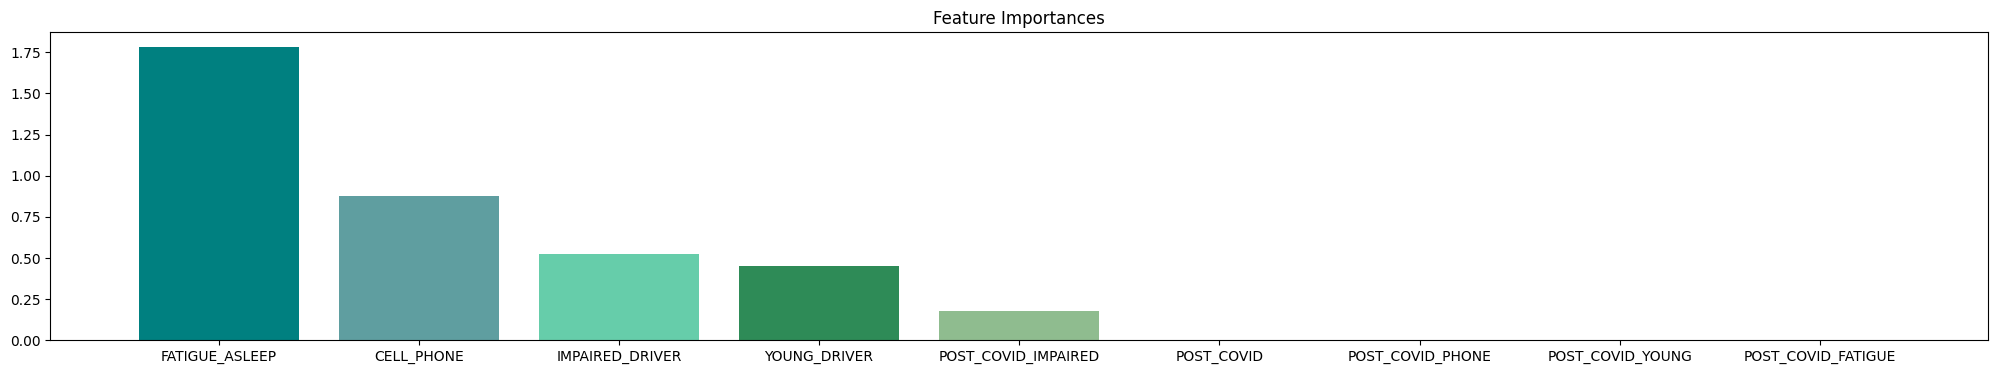

In [78]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names[i],v))
# plot feature importance
#plt.bar(feature_names, importances, color=colors)
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
fig = plt.gcf() # Get current figure
fig.set_size_inches(25, 4)
plt.title('Feature Importances')
plt.show()

Feature: POST_COVID, Score: 0.00000
Feature: IMPAIRED_DRIVER, Score: 0.52162
Feature: CELL_PHONE, Score: 0.87465
Feature: YOUNG_DRIVER, Score: 0.45233
Feature: FATIGUE_ASLEEP, Score: 1.78209
Feature: POST_COVID_IMPAIRED, Score: 0.17649
Feature: POST_COVID_PHONE, Score: 0.00000
Feature: POST_COVID_YOUNG, Score: 0.00000
Feature: POST_COVID_FATIGUE, Score: 0.00000


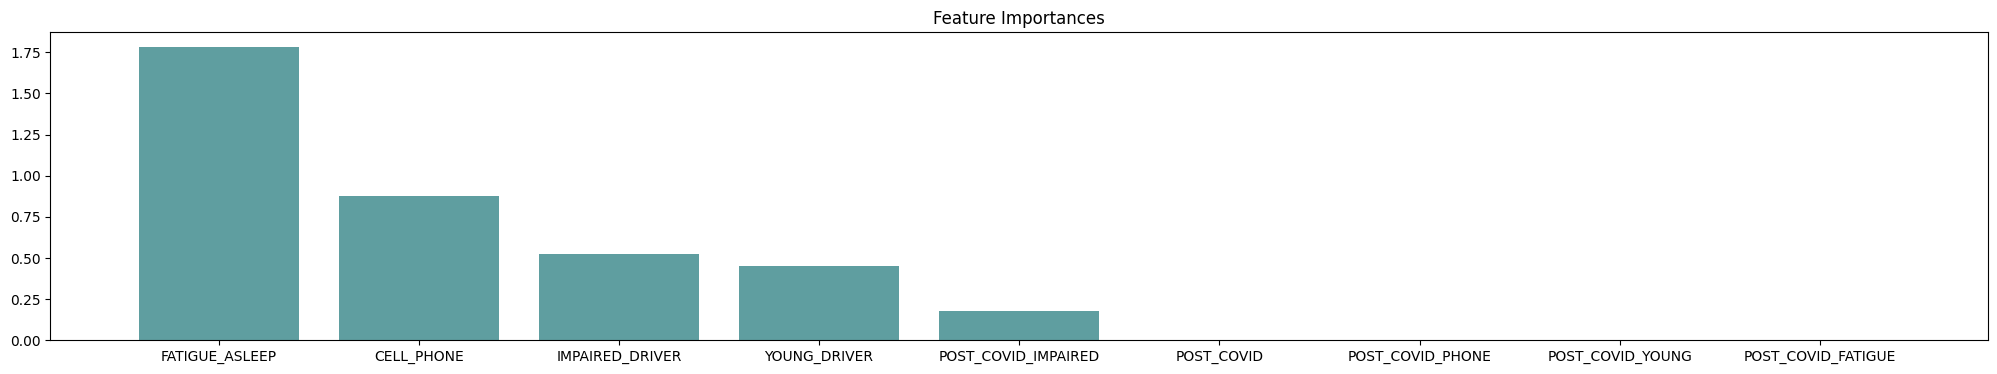

In [79]:
for i,v in enumerate(importances):
	#print('Feature: %0d, Score: %.5f' % (i,v))
  print('Feature: %s, Score: %.5f' % (feature_names[i],v))
# plot feature importance
#plt.bar(feature_names, importances, color='cadetblue')
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='cadetblue')
fig = plt.gcf() # Get current figure
fig.set_size_inches(25, 4)
plt.title('Feature Importances')
plt.show()

In [80]:
y_pred = lgr_pipeline.predict(X_test)

#### Confusion matrix

In [81]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 59.26%


In [82]:
conf_matrix = confusion_matrix(y_test, y_pred)

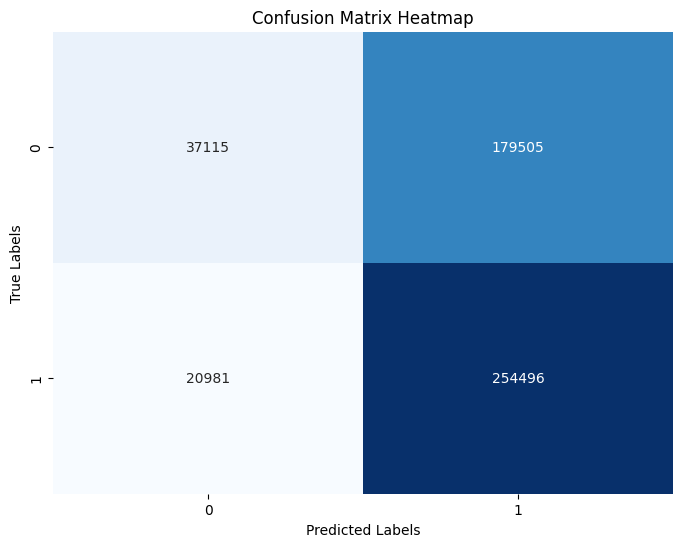

In [83]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Performance metrics

In [84]:
# Predicted probabilities for the class 1
y_pred_proba = lgr_pipeline.predict_proba(X_test)[:, 1]

In [85]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [86]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [87]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [88]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

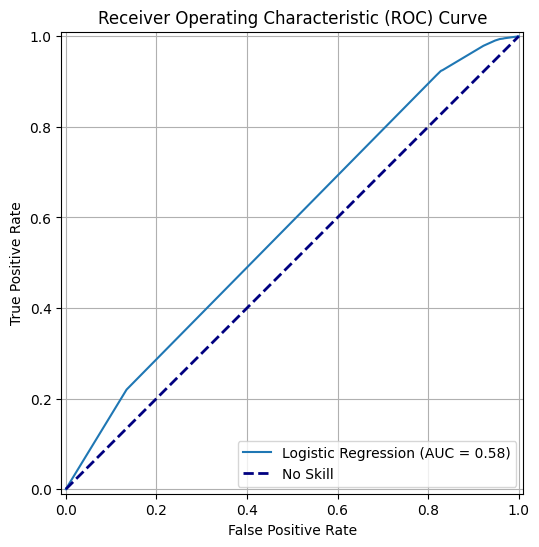

In [89]:
# Plot the ROC curve
# Using RocCurveDisplay.from_estimator is the recommended method in modern scikit-learn
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lgr_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")

# Plot the "no skill" or chance level baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='No Skill')

# Customize the plot
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

In [90]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'LogisticRegressionCV'

In [91]:
aggdrv_lgr = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [92]:
aggdrv_lgr['LogisticRegressionCV'] = [round(x, 4) for x in aggdrv_lgr['LogisticRegressionCV']]

In [93]:
aggdrv_lgr

,Measure,LogisticRegressionCV
0,Accuracy,0.5926
1,Precision,0.5864
2,Recall,0.9238
3,F1 Score,0.7174
4,ROC AUC,0.5783


In [94]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.17      0.27    216620
           1       0.59      0.92      0.72    275477

    accuracy                           0.59    492097
   macro avg       0.61      0.55      0.49    492097
weighted avg       0.61      0.59      0.52    492097



#### Confidence intervals for ROC AUC
https://www.w3tutorials.net/blog/scikit-learn-roc-curve-with-confidence-intervals/

In [95]:
# Compute FPR, TPR, and thresholds for the baseline model
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
baseline_auc = auc(fpr, tpr)

print(f"Baseline AUC: {baseline_auc:.3f}")

Baseline AUC: 0.578


In [96]:
n_bootstraps = 1000  # Number of resamples (more = more stable CIs, but slower)
random_seed = 42  # For reproducibility
bootstrapped_tprs = []  # Store TPRs from each bootstrap
bootstrapped_aucs = []  # Store AUCs from each bootstrap
mean_fpr = np.linspace(0, 1, 100)  # Common grid to align FPRs across bootstraps

In [97]:
y_test = np.asarray(y_test)
y_pred_proba = np.asarray(y_pred_proba)

In [98]:
np.random.seed(random_seed)
for i in range(n_bootstraps):
    # Step 1: Resample test set with replacement
    indices = np.random.choice(len(y_test), len(y_test), replace=True)
    y_test_bootstrap = y_test[indices]
    y_pred_proba_bootstrap = y_pred_proba[indices]

    # Skip resamples with only one class (avoids errors in roc_curve)
    if len(np.unique(y_test_bootstrap)) < 2:
        continue

    # Step 2: Compute ROC curve for the bootstrap sample
    fpr_bootstrap, tpr_bootstrap, _ = roc_curve(y_test_bootstrap, y_pred_proba_bootstrap)

    # Step 3: Interpolate TPR to the common FPR grid (mean_fpr)
    f = interp1d(fpr_bootstrap, tpr_bootstrap, bounds_error=False, fill_value="extrapolate")
    tpr_interp = f(mean_fpr)
    tpr_interp[0] = 0.0  # Ensure TPR starts at 0 when FPR=0
    bootstrapped_tprs.append(tpr_interp)

    # Step 4: Compute and store AUC for the bootstrap sample
    bootstrap_auc = roc_auc_score(y_test_bootstrap, y_pred_proba_bootstrap)
    bootstrapped_aucs.append(bootstrap_auc)

In [99]:
# Compute mean TPR across all bootstraps
mean_tpr = np.mean(bootstrapped_tprs, axis=0)
mean_tpr[-1] = 1.0  # Ensure TPR ends at 1 when FPR=1

# Compute 95% CI (2.5th and 97.5th percentiles of bootstrapped TPRs)
tprs_lower = np.percentile(bootstrapped_tprs, 2.5, axis=0)
tprs_upper = np.percentile(bootstrapped_tprs, 97.5, axis=0)

# Compute 95% CI for AUC
auc_ci_lower = np.percentile(bootstrapped_aucs, 2.5)
auc_ci_upper = np.percentile(bootstrapped_aucs, 97.5)

print(f"AUC 95% CI: [{auc_ci_lower:.3f}, {auc_ci_upper:.3f}]")
# Output: AUC 95% CI: [0.986, 1.000]

AUC 95% CI: [0.577, 0.580]


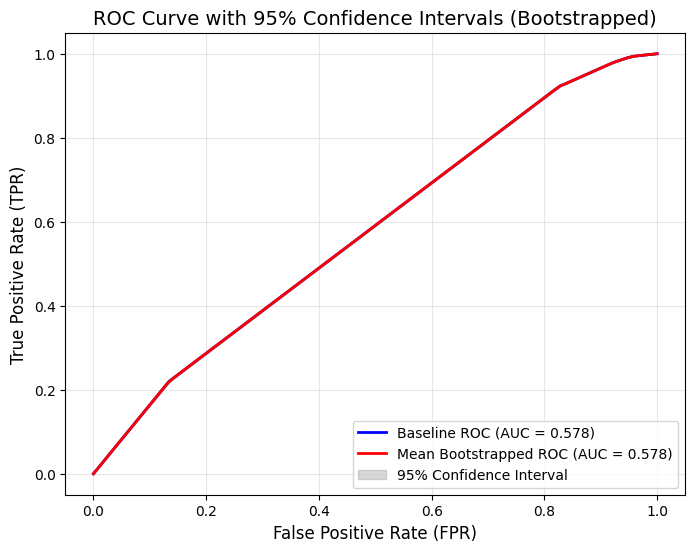

In [100]:
plt.figure(figsize=(8, 6))

# Plot baseline ROC curve
plt.plot(fpr, tpr, lw=2, label=f"Baseline ROC (AUC = {baseline_auc:.3f})", color="blue")

# Plot mean ROC curve from bootstraps
plt.plot(mean_fpr, mean_tpr, lw=2, label=f"Mean Bootstrapped ROC (AUC = {np.mean(bootstrapped_aucs):.3f})", color="red")

# Shade the 95% CI region
plt.fill_between(
    mean_fpr, tprs_lower, tprs_upper,
    color="gray", alpha=0.3, label="95% Confidence Interval"
)

# Add labels and legend
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("ROC Curve with 95% Confidence Intervals (Bootstrapped)", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### <a id='sm-int'>Logistic Regression with Statsmodels and Interaction</a>

In [101]:
X_train = sm.add_constant(X_train)

In [102]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y_train.values, X_train)

In [103]:
result = model.fit()

Optimization terminated successfully.
         Current function value: 0.668267
         Iterations 6


In [104]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:              1968387
Model:                          Logit   Df Residuals:                  1968377
Method:                           MLE   Df Model:                            9
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.02582
Time:                        16:16:01   Log-Likelihood:            -1.3154e+06
converged:                       True   LL-Null:                   -1.3503e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2583      0.002    132.445      0.000       0.254       0.262
POST_COVID             -0.0050      0.004     -1.209      0.226      -0.013       0.003
IMPAIRED_DRIVER 

In [105]:
importances = result.params.abs().sort_values(ascending=False)
print(importances.sort_values(ascending=False))

FATIGUE_ASLEEP         2.077946
CELL_PHONE             1.078199
IMPAIRED_DRIVER        0.527614
YOUNG_DRIVER           0.455133
POST_COVID_PHONE       0.306628
POST_COVID_IMPAIRED    0.280870
const                  0.258256
POST_COVID_YOUNG       0.066079
POST_COVID_FATIGUE     0.010536
POST_COVID             0.004972
dtype: float64


In [106]:
importances

,0
FATIGUE_ASLEEP,2.077946
CELL_PHONE,1.078199
IMPAIRED_DRIVER,0.527614
YOUNG_DRIVER,0.455133
POST_COVID_PHONE,0.306628
POST_COVID_IMPAIRED,0.280870
const,0.258256
POST_COVID_YOUNG,0.066079
POST_COVID_FATIGUE,0.010536
POST_COVID,0.004972


In [107]:
coeffs = result.params.abs().values
feature_names = result.params.index

In [108]:
# Create a clean DataFrame
summary_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs}).sort_values(by='Coefficient', ascending=False)
print(summary_df)

               Feature  Coefficient
5       FATIGUE_ASLEEP     2.077946
3           CELL_PHONE     1.078199
2      IMPAIRED_DRIVER     0.527614
4         YOUNG_DRIVER     0.455133
7     POST_COVID_PHONE     0.306628
6  POST_COVID_IMPAIRED     0.280870
0                const     0.258256
8     POST_COVID_YOUNG     0.066079
9   POST_COVID_FATIGUE     0.010536
1           POST_COVID     0.004972


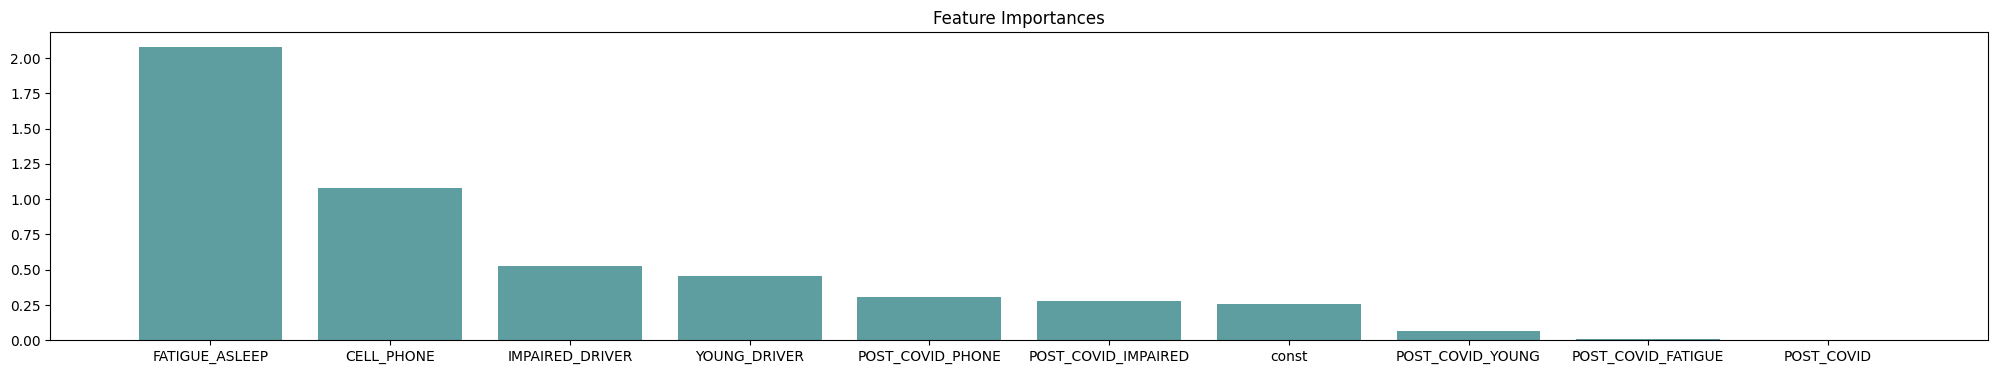

In [109]:
# plot feature importance
#plt.bar(feature_names, importances, color='cadetblue')
plt.bar(summary_df['Feature'], summary_df['Coefficient'], color='cadetblue')
fig = plt.gcf() # Get current figure
fig.set_size_inches(25, 4)
plt.title('Feature Importances')
plt.show()

### <a id='prep-rob'>Preprocessing for TIme-Based Robustness Testing</a>

In [110]:
#df1 = df.loc[df['URBAN_RURALx']=='Urbanized'].copy()
df1 = df.loc[(df['CRASH_DATE'] >= pd.to_datetime('2019-03-01', format='%Y-%m-%d')) & (df['CRASH_DATE'] < pd.to_datetime('2021-03-01', format='%Y-%m-%d'))].copy()

In [111]:
#df2 = df.loc[df['URBAN_RURALx']=='Rural'].copy()
df2 = df.loc[df['CRASH_DATE'] >= pd.to_datetime('2015-03-01', format='%Y-%m-%d')].copy()

In [112]:
#df.shape[0] == df1.shape[0] + df2.shape[0]

In [113]:
X1 = df1.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'CELL_PHONE',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_PHONE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE']].copy()

In [114]:
X2 = df2.loc[:,['POST_COVID',
 'IMPAIRED_DRIVER',
 'CELL_PHONE',
 'YOUNG_DRIVER',
 'FATIGUE_ASLEEP',
  'POST_COVID_IMPAIRED',
  'POST_COVID_PHONE',
  'POST_COVID_YOUNG',
  'POST_COVID_FATIGUE']].copy()

In [115]:
y1 = df1['AGGRESSIVE_DRIVING']
y2 = df2['AGGRESSIVE_DRIVING']

In [116]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=42)

In [117]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)

In [118]:
add_constant_func = FunctionTransformer(sm.add_constant)

### <a id='sm-rob'>Robustness Testing with Statsmodels</a>

In [119]:
X1_train = sm.add_constant(X1_train)

In [120]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y1_train.values, X1_train)

In [121]:
result1 = model.fit()

Optimization terminated successfully.
         Current function value: 0.670243
         Iterations 6


In [122]:
print(result1.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               180806
Model:                          Logit   Df Residuals:                   180796
Method:                           MLE   Df Model:                            9
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.02603
Time:                        16:16:07   Log-Likelihood:            -1.2118e+05
converged:                       True   LL-Null:                   -1.2442e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2568      0.008     34.105      0.000       0.242       0.272
POST_COVID             -0.0587      0.011     -5.259      0.000      -0.081      -0.037
IMPAIRED_DRIVER 

In [123]:
importances1 = result1.params.abs().sort_values(ascending=False)
print(importances1.sort_values(ascending=False))

FATIGUE_ASLEEP         1.947719
CELL_PHONE             1.119949
IMPAIRED_DRIVER        0.733449
YOUNG_DRIVER           0.481416
const                  0.256830
POST_COVID             0.058721
POST_COVID_IMPAIRED    0.045150
POST_COVID_FATIGUE     0.042385
POST_COVID_PHONE       0.031981
POST_COVID_YOUNG       0.003688
dtype: float64


In [124]:
X2_train = sm.add_constant(X2_train)

In [125]:
#X_train_sm = sm.add_constant(X_train_final)
model = sm.Logit(y2_train.values, X2_train)

In [126]:
result2 = model.fit()

Optimization terminated successfully.
         Current function value: 0.666563
         Iterations 6


In [127]:
print(result2.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               940504
Model:                          Logit   Df Residuals:                   940494
Method:                           MLE   Df Model:                            9
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.02943
Time:                        16:16:14   Log-Likelihood:            -6.2691e+05
converged:                       True   LL-Null:                   -6.4592e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2752      0.003     82.636      0.000       0.269       0.282
POST_COVID             -0.0237      0.005     -4.813      0.000      -0.033      -0.014
IMPAIRED_DRIVER 

In [128]:
importances2 = result2.params.abs().sort_values(ascending=False)
print(importances2.sort_values(ascending=False))

FATIGUE_ASLEEP         2.015361
CELL_PHONE             1.172605
IMPAIRED_DRIVER        0.690685
YOUNG_DRIVER           0.452147
const                  0.275170
POST_COVID_PHONE       0.211207
POST_COVID_IMPAIRED    0.109152
POST_COVID_YOUNG       0.070039
POST_COVID_FATIGUE     0.055407
POST_COVID             0.023671
dtype: float64


In [129]:
print(importances1.sort_values(ascending=False))

FATIGUE_ASLEEP         1.947719
CELL_PHONE             1.119949
IMPAIRED_DRIVER        0.733449
YOUNG_DRIVER           0.481416
const                  0.256830
POST_COVID             0.058721
POST_COVID_IMPAIRED    0.045150
POST_COVID_FATIGUE     0.042385
POST_COVID_PHONE       0.031981
POST_COVID_YOUNG       0.003688
dtype: float64
